In [1]:
import kagglehub


path = kagglehub.dataset_download("patrickb1912/ipl-complete-dataset-20082020")

print("Path to dataset files:", path)

100%|██████████| 1.82M/1.82M [00:00<00:00, 115MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/patrickb1912/ipl-complete-dataset-20082020/versions/3


In [4]:
import pandas as pd
import os

match = pd.read_csv(os.path.join(path, "matches.csv"))
delivery = pd.read_csv(os.path.join(path, "deliveries.csv"))

# Clean the match data
match = match.dropna(subset=['winner'])
match = match.drop_duplicates()

In [8]:
import pandas as pd

# Map standard column names based on dataset inspection
bat_col = 'batter' if 'batter' in delivery.columns else 'batsman'
run_col = 'batsman_runs' if 'batsman_runs' in delivery.columns else 'batter_runs'
bowl_col = 'bowler'

# 1. Calculate Batting Statistics
# Total runs per batsman
batting_runs = delivery.groupby(bat_col)[run_col].sum()

# Total balls faced (excluding wides)
# In this version, we check 'extras_type' for 'wides'
batting_balls = delivery[delivery['extras_type'] != 'wides'].groupby(bat_col).size()

batting_stats = pd.DataFrame({'total_runs': batting_runs, 'balls_faced': batting_balls})
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['balls_faced']) * 100

# 2. Calculate Bowling Statistics
# Total runs conceded (standard 'total_runs' column includes batsman runs + extras)
bowling_runs = delivery.groupby(bowl_col)['total_runs'].sum()

# Total balls bowled (excluding wides and noballs for standard over/economy calculation)
bowling_balls = delivery[~delivery['extras_type'].isin(['wides', 'noballs'])].groupby(bowl_col).size()

# Wickets (excluding certain dismissal types like run out, retired hurt)
valid_wickets = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets = delivery[delivery['dismissal_kind'].isin(valid_wickets)].groupby(bowl_col).size()

# 3. Economy Rate
bowling_stats = pd.DataFrame({'runs_conceded': bowling_runs, 'balls_bowled': bowling_balls, 'wickets': wickets})
bowling_stats['wickets'] = bowling_stats['wickets'].fillna(0).astype(int)
bowling_stats['economy'] = (bowling_stats['runs_conceded'] / (bowling_stats['balls_bowled'] / 6))

# 4. Merge Batting and Bowling Metrics
player_stats = pd.merge(batting_stats, bowling_stats, left_index=True, right_index=True, how='outer')

print("Player Statistics Summary (Top 5):")
print(player_stats.head())


Player Statistics Summary (Top 5):
                total_runs  balls_faced  strike_rate  runs_conceded  \
A Ashish Reddy       280.0        193.0   145.077720          400.0   
A Badoni             634.0        473.0   134.038055           37.0   
A Chandila             4.0          7.0    57.142857          245.0   
A Chopra              53.0         71.0    74.647887            NaN   
A Choudhary           25.0         20.0   125.000000          144.0   

                balls_bowled  wickets   economy  
A Ashish Reddy         262.0     18.0  9.160305  
A Badoni                25.0      2.0  8.880000  
A Chandila             234.0     11.0  6.282051  
A Chopra                 NaN      NaN       NaN  
A Choudhary            101.0      5.0  8.554455  


In [9]:
import pandas as pd

# 1. Aggregate number of wins per team
team_wins = match['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'total_wins']

# 2. Calculate win percentage based on toss impact
# Filter matches where toss winner is also the match winner
toss_win_match = match[match['toss_winner'] == match['winner']]
toss_win_counts = toss_win_match['winner'].value_counts()
total_matches_played = pd.concat([match['team1'], match['team2']]).value_counts()

toss_impact = pd.DataFrame({
    'toss_and_match_wins': toss_win_counts,
    'total_matches': total_matches_played
}).fillna(0)
toss_impact['toss_win_match_win_pct'] = (toss_impact['toss_and_match_wins'] / toss_impact['total_matches']) * 100

# 3. Wins per team per season
seasonal_wins = match.groupby(['season', 'winner']).size().reset_index(name='wins')

# 4. Analyze match outcomes by venue
venue_performance = match.groupby(['venue', 'winner']).size().reset_index(name='wins')
# Identify top team per venue
top_venue_teams = venue_performance.sort_values(['venue', 'wins'], ascending=[True, False]).drop_duplicates('venue')

# 5. Create a summary dictionary for these metrics
match_outcomes_summary = {
    'overall_wins': team_wins,
    'toss_efficiency': toss_impact,
    'seasonal_trends': seasonal_wins,
    'venue_leaders': top_venue_teams
}

print("Top 5 Teams by Total Wins:")
print(team_wins.head())
print("\nTop 5 Venues and their Most Successful Teams:")
print(top_venue_teams.head())


Top 5 Teams by Total Wins:
                          team  total_wins
0               Mumbai Indians         144
1          Chennai Super Kings         138
2        Kolkata Knight Riders         131
3  Royal Challengers Bangalore         116
4             Rajasthan Royals         112

Top 5 Venues and their Most Successful Teams:
                                                venue                winner  \
1                                Arun Jaitley Stadium        Delhi Capitals   
8                         Arun Jaitley Stadium, Delhi        Delhi Capitals   
14                                   Barabati Stadium       Deccan Chargers   
17                Barsapara Cricket Stadium, Guwahati          Punjab Kings   
22  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...  Lucknow Super Giants   

    wins  
1      4  
8      6  
14     3  
17     2  
22     7  


/tmp/ipykernel_339/3652104877.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mom_awards', y='player', data=top_10_mom, palette='viridis')


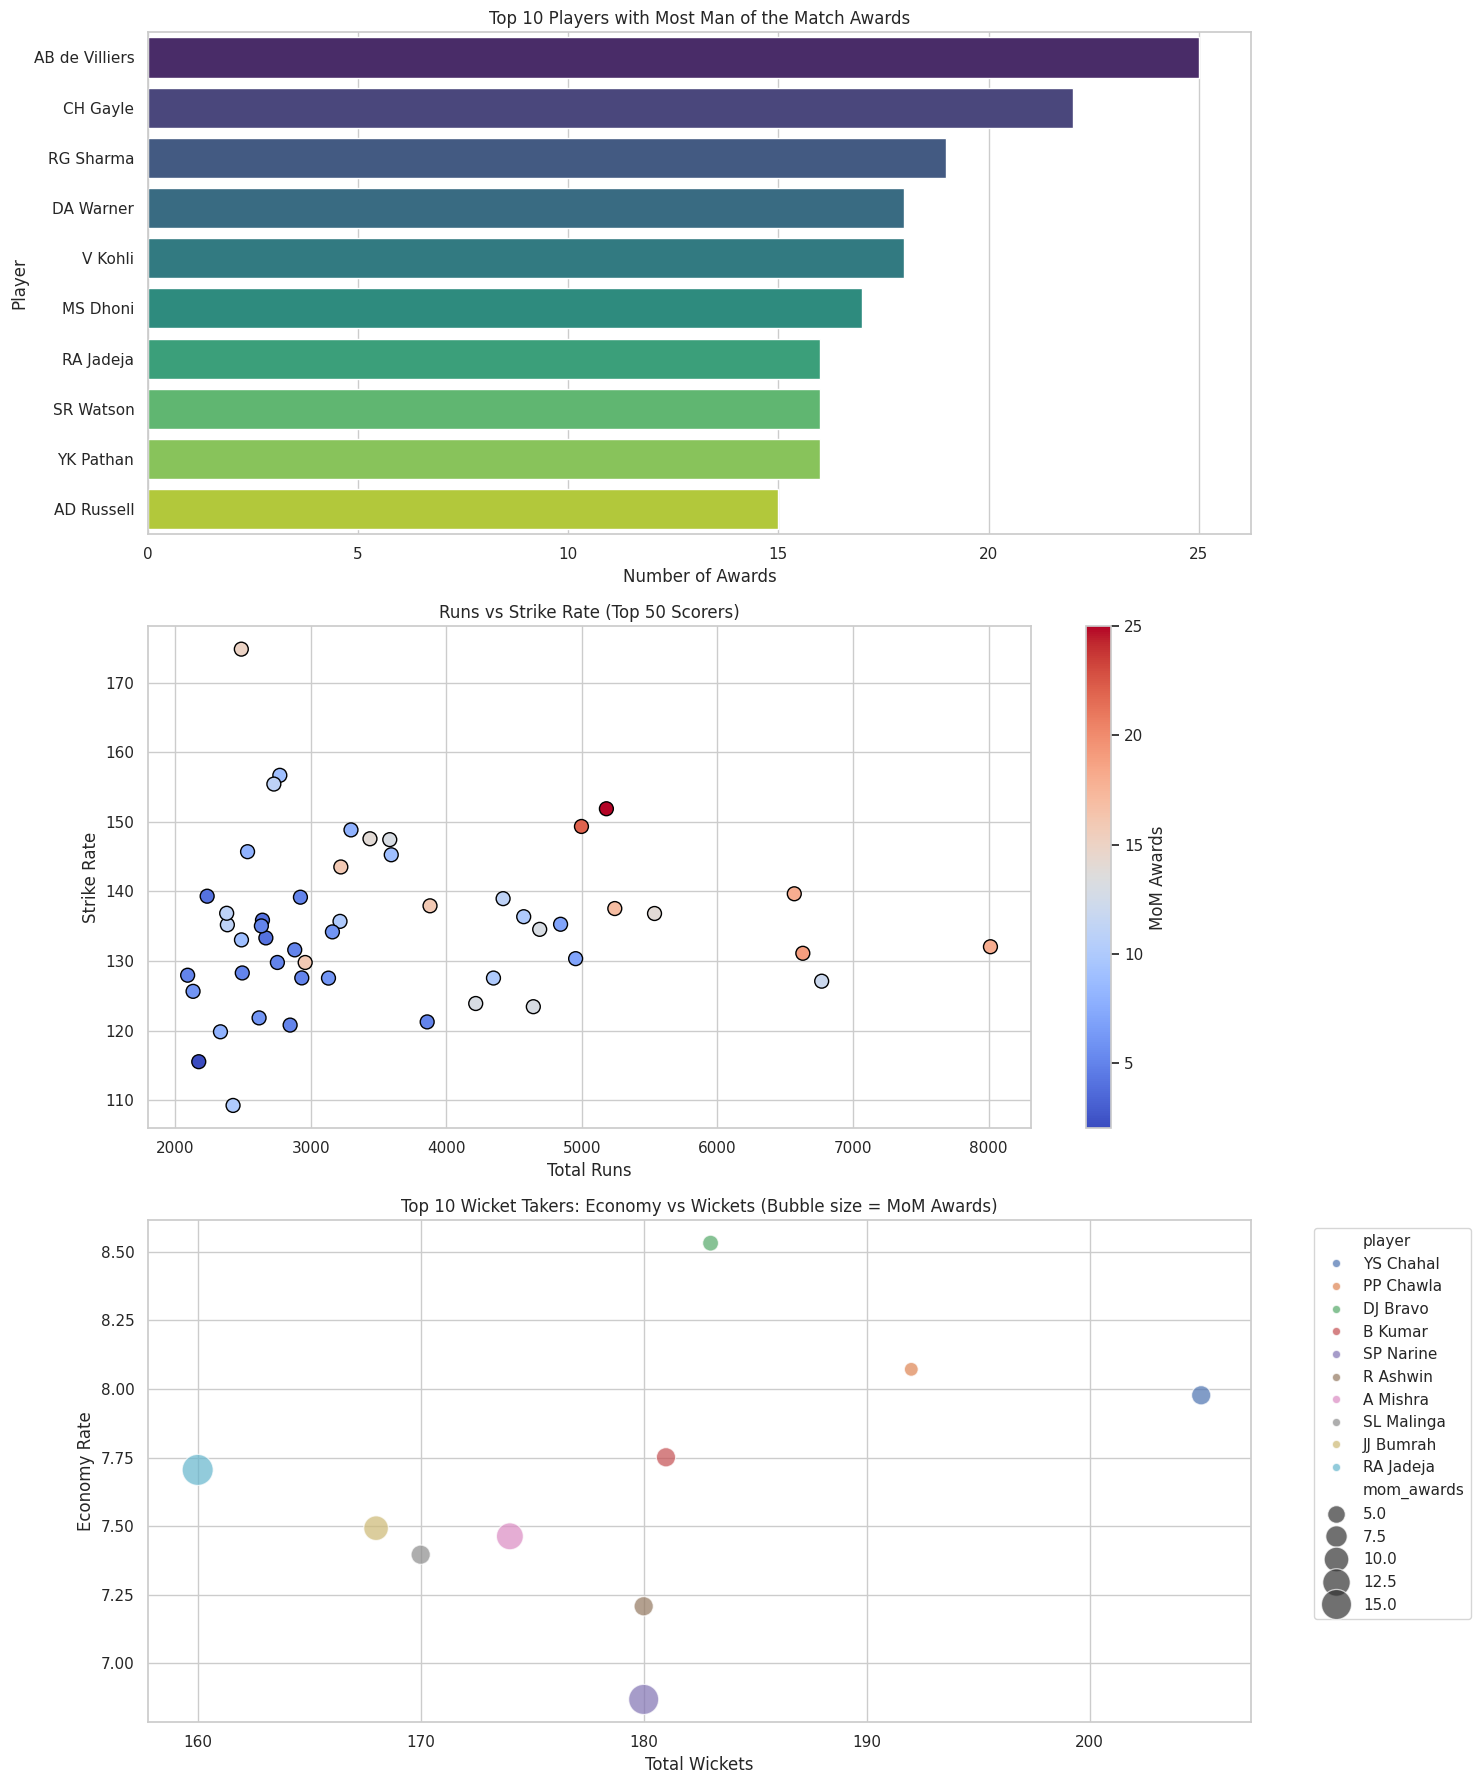

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify 'Man of the Match' (player_of_match) winners
mom_counts = match['player_of_match'].value_counts().reset_index()
mom_counts.columns = ['player', 'mom_awards']

# 2. Merge with player_stats
# Since player_stats index is the player name, we'll reset index or use it for merging
player_stats_reset = player_stats.reset_index().rename(columns={'index': 'player'})
merged_stats = pd.merge(player_stats_reset, mom_counts, on='player', how='left').fillna({'mom_awards': 0})

# Set plot style
sns.set(style='whitegrid')
plt.figure(figsize=(15, 18))

# 3. Bar chart: Top 10 Player of the Match winners
plt.subplot(3, 1, 1)
top_10_mom = merged_stats.sort_values(by='mom_awards', ascending=False).head(10)
sns.barplot(x='mom_awards', y='player', data=top_10_mom, palette='viridis')
plt.title('Top 10 Players with Most Man of the Match Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')

# 4. Scatter plot: Total Runs vs Strike Rate for top 50 scorers
top_50_scorers = merged_stats.sort_values(by='total_runs', ascending=False).head(50)
plt.subplot(3, 1, 2)
scatter = plt.scatter(top_50_scorers['total_runs'], top_50_scorers['strike_rate'],
                      c=top_50_scorers['mom_awards'], cmap='coolwarm', s=100, edgecolors='black')
plt.colorbar(scatter, label='MoM Awards')
plt.title('Runs vs Strike Rate (Top 50 Scorers)')
plt.xlabel('Total Runs')
plt.ylabel('Strike Rate')

# 5. Bubble chart: Top 10 Wicket Takers (Economy vs Wickets)
top_10_bowlers = merged_stats.sort_values(by='wickets', ascending=False).head(10)
plt.subplot(3, 1, 3)
sns.scatterplot(x='wickets', y='economy', size='mom_awards', data=top_10_bowlers,
                hue='player', sizes=(100, 500), alpha=0.7)
plt.title('Top 10 Wicket Takers: Economy vs Wickets (Bubble size = MoM Awards)')
plt.xlabel('Total Wickets')
plt.ylabel('Economy Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# Calculate total runs scored by each team
team_total_runs = delivery.groupby('batting_team')['total_runs'].sum()

# Count total matches played by each team (as team1 or team2)
matches_played = pd.concat([match['team1'], match['team2']]).value_counts()

# Create a DataFrame for average runs
avg_runs_per_team = pd.DataFrame({
    'total_runs': team_total_runs,
    'matches_played': matches_played
}).dropna()

avg_runs_per_team['avg_runs_per_match'] = avg_runs_per_team['total_runs'] / avg_runs_per_team['matches_played']
avg_runs_per_team = avg_runs_per_team.sort_values(by='avg_runs_per_match', ascending=False)

print("Average Runs Scored Per Team Per Match:")
display(avg_runs_per_team[['avg_runs_per_match']])

Average Runs Scored Per Team Per Match:


,avg_runs_per_match
Royal Challengers Bengaluru,195.333333
Lucknow Super Giants,174.651163
Gujarat Titans,172.377778
Punjab Kings,170.285714
Delhi Capitals,163.736264
Chennai Super Kings,162.991561
Gujarat Lions,162.066667
Mumbai Indians,161.593870
Sunrisers Hyderabad,159.730769
Royal Challengers Bangalore,159.037975


In [12]:
import numpy as np

# 1. Group by match_id and batting_team to sum total_runs per match
team_match_scores = delivery.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()

# 2. Rename the column to 'match_runs'
team_match_scores.rename(columns={'total_runs': 'match_runs'}, inplace=True)

# 3. Inspect the first few rows
print("First 5 rows of team_match_scores:")
print(team_match_scores.head())

# 4. Create a list of arrays for ANOVA
# Each array will contain the 'match_runs' for a specific team
groups = [group['match_runs'].values for name, group in team_match_scores.groupby('batting_team')]

print(f"\nPrepared {len(groups)} team groups for ANOVA test.")

First 5 rows of team_match_scores:
   match_id                 batting_team  match_runs
0    335982        Kolkata Knight Riders         222
1    335982  Royal Challengers Bangalore          82
2    335983          Chennai Super Kings         240
3    335983              Kings XI Punjab         207
4    335984             Delhi Daredevils         132

Prepared 19 team groups for ANOVA test.


In [13]:
from scipy import stats

# 1. Perform the One-Way ANOVA test
# We unpack the 'groups' list which contains match_runs arrays for each team
f_stat, p_value = stats.f_oneway(*groups)

# 2. Print the results
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# 3. Brief interpretation for the next step
alpha = 0.05
if p_value < alpha:
    print(f"\nInterpretation: Since the p-value ({p_value:.4e}) is less than {alpha}, we reject the null hypothesis.")
    print("There are statistically significant differences in the mean runs scored between at least two IPL teams.")
else:
    print(f"\nInterpretation: Since the p-value ({p_value:.4e}) is greater than {alpha}, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the mean runs scored between the IPL teams.")

F-statistic: 4.7866
p-value: 1.2223e-10

Interpretation: Since the p-value (1.2223e-10) is less than 0.05, we reject the null hypothesis.
There are statistically significant differences in the mean runs scored between at least two IPL teams.


/tmp/ipykernel_339/3857449453.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='batting_team', y='match_runs', data=team_match_scores, palette='Set3')


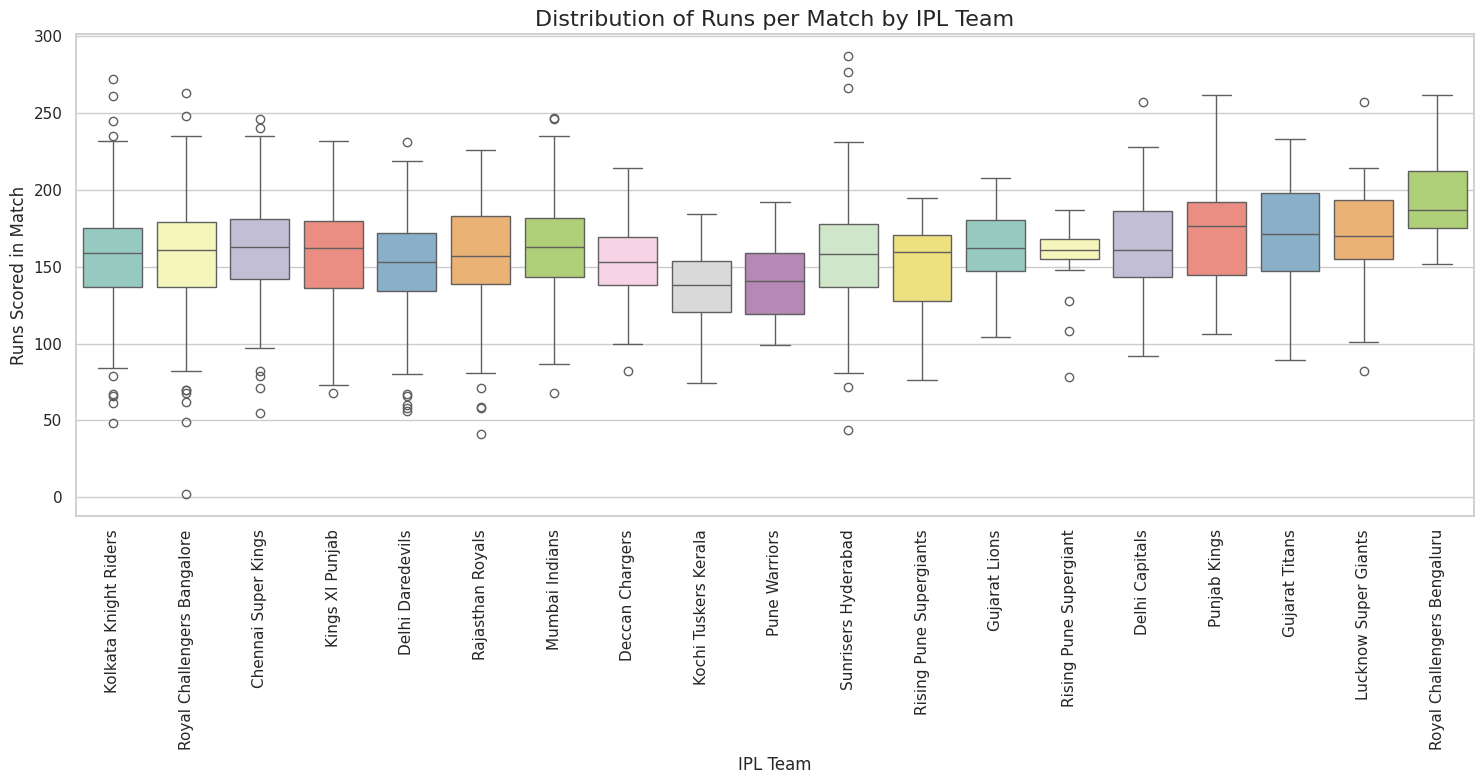

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size for better visibility of 19 teams
plt.figure(figsize=(15, 8))

# 2. Create the box plot using team_match_scores
sns.boxplot(x='batting_team', y='match_runs', data=team_match_scores, palette='Set3')

# 3. Add titles and labels
plt.title('Distribution of Runs per Match by IPL Team', fontsize=16)
plt.xlabel('IPL Team', fontsize=12)
plt.ylabel('Runs Scored in Match', fontsize=12)

# 4. Rotate x-axis labels for readability
plt.xticks(rotation=90)

# 5. Display the plot
plt.tight_layout()
plt.show()

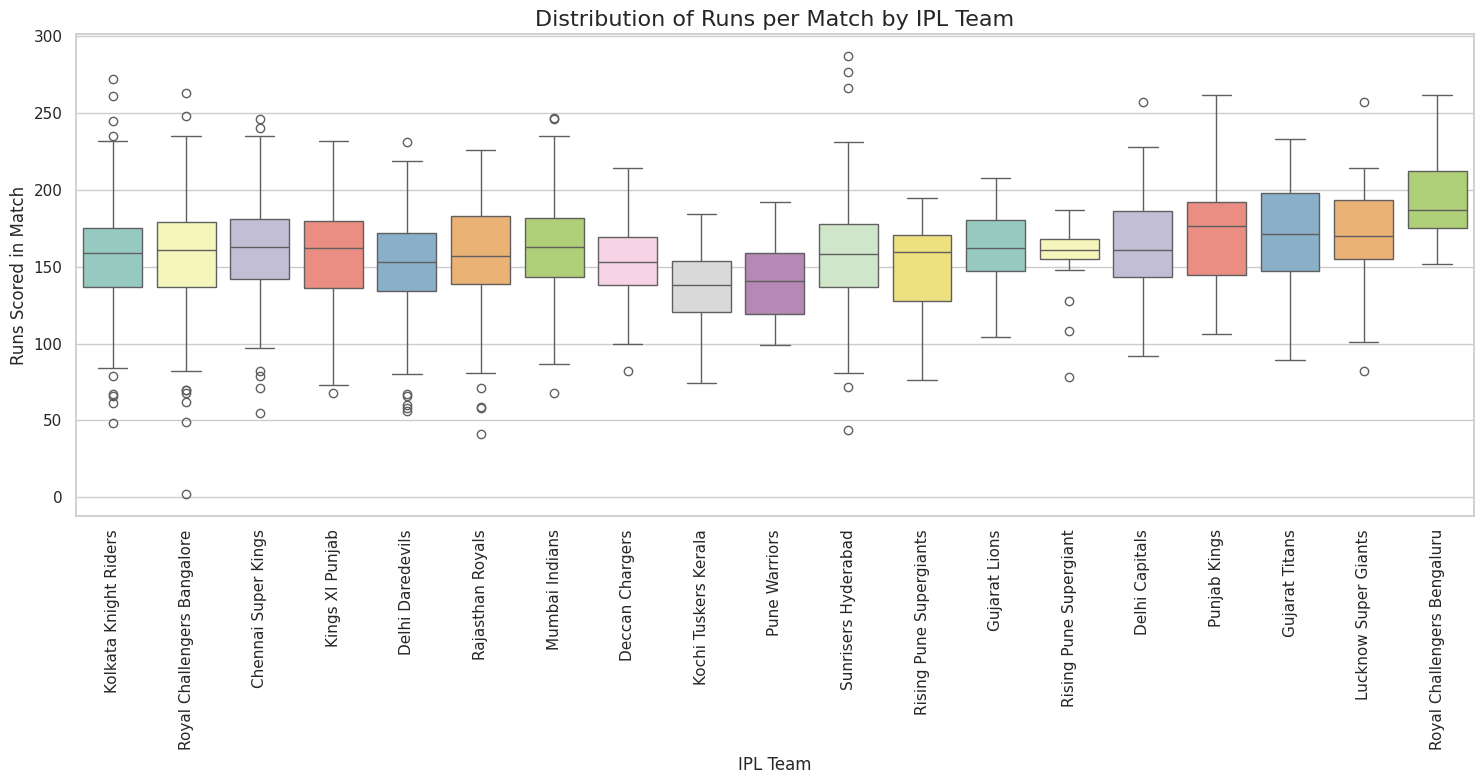

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size for better visibility of 19 teams
plt.figure(figsize=(15, 8))

# 2. Create the box plot using team_match_scores
# Assign x to hue and set legend=False to avoid the palette warning
sns.boxplot(x='batting_team', y='match_runs', data=team_match_scores, palette='Set3', hue='batting_team', legend=False)

# 3. Add titles and labels
plt.title('Distribution of Runs per Match by IPL Team', fontsize=16)
plt.xlabel('IPL Team', fontsize=12)
plt.ylabel('Runs Scored in Match', fontsize=12)

# 4. Rotate x-axis labels for readability
plt.xticks(rotation=90)

# 5. Display the plot
plt.tight_layout()
plt.show()

# Task
Perform feature engineering on the IPL dataset located at "/root/.cache/kagglehub/datasets/patrickb1912/ipl-complete-dataset-20082020/versions/3" to create predictors such as toss outcome and home-ground advantage. Preprocess the data, encode categorical variables, and split it into training and testing sets. Train a Logistic Regression model to predict whether the team batting first wins, evaluate its performance using an accuracy score and confusion matrix, and visualize feature importance to identify the most significant predictors.

## Feature Engineering for Win Prediction

### Subtask:
Create predictive features from the match and delivery datasets to identify the team batting first and assess factors like toss impact and home advantage.


**Reasoning**:
I will define the target variable 'bat_first_win', identify the team batting first, and create features for toss decision, home advantage, and team experience as instructed.



In [16]:
import pandas as pd
import numpy as np

# 1. Define Team Batting First and Target Variable 'bat_first_win'
def get_bat_first(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    else:
        return row['team1'] if row['team1'] != row['toss_winner'] else row['team2']

match['team_bat_first'] = match.apply(get_bat_first, axis=1)
match['bat_first_win'] = (match['team_bat_first'] == match['winner']).astype(int)

# 2. Create 'toss_winner_is_bat_first' feature
match['toss_winner_is_bat_first'] = (match['toss_decision'] == 'bat').astype(int)

# 3. Create 'home_advantage' feature
# Mapping major teams to their primary home grounds
home_ground_map = {
    'Mumbai Indians': 'Wankhede Stadium',
    'Chennai Super Kings': 'MA Chidambaram Stadium, Chepauk',
    'Kolkata Knight Riders': 'Eden Gardens',
    'Royal Challengers Bangalore': 'M Chinnaswamy Stadium',
    'Rajasthan Royals': 'Sawai Mansingh Stadium',
    'Kings XI Punjab': 'Punjab Cricket Association Stadium, Mohali',
    'Sunrisers Hyderabad': 'Rajiv Gandhi International Stadium, Uppal',
    'Delhi Daredevils': 'Feroz Shah Kotla',
    'Delhi Capitals': 'Arun Jaitley Stadium'
}

def check_home_advantage(row):
    home_venue = home_ground_map.get(row['team_bat_first'], 'None')
    return 1 if home_venue in str(row['venue']) else 0

match['is_home_game'] = match.apply(check_home_advantage, axis=1)

# 4. Calculate 'team_experience' (cumulative matches played by the team)
all_teams_played = pd.concat([match['team1'], match['team2']])
team_match_counts = match.groupby('team_bat_first').cumcount()
match['team_bat_first_experience'] = team_match_counts

# 5. Select final feature set and clean nulls
feature_cols = ['venue', 'toss_winner', 'toss_decision', 'is_home_game', 'team_bat_first_experience', 'bat_first_win']
model_df = match[feature_cols].dropna().copy()

print("Feature Engineering Complete.")
print(f"Model Dataframe Shape: {model_df.shape}")
display(model_df.head())


Feature Engineering Complete.
Model Dataframe Shape: (1090, 6)


,venue,toss_winner,toss_decision,is_home_game,team_bat_first_experience,bat_first_win
0,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,0,0,1
1,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,0,0,1
2,Feroz Shah Kotla,Rajasthan Royals,bat,0,0,0
3,Wankhede Stadium,Mumbai Indians,bat,1,0,0
4,Eden Gardens,Deccan Chargers,bat,0,0,0


## Preprocess and Split Data

### Subtask:
Prepare the feature-engineered dataset for machine learning by encoding categorical variables and splitting it into training and testing sets.


**Reasoning**:
I will encode the categorical features 'venue', 'toss_winner', and 'toss_decision' using LabelEncoder, define the features and target, and then split the data into training and testing sets as per the instructions.



In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Initialize LabelEncoder
le = LabelEncoder()

# 2. Identify categorical columns and encode them
cat_cols = ['venue', 'toss_winner', 'toss_decision']
for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# 3. Define feature matrix X and target vector y
X = model_df.drop('bat_first_win', axis=1)
y = model_df['bat_first_win']

# 4. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print('\nEncoded Feature Sample:')
display(X_train.head())

X_train shape: (872, 5)
X_test shape: (218, 5)
y_train shape: (872,)
y_test shape: (218,)

Encoded Feature Sample:


,venue,toss_winner,toss_decision,is_home_game,team_bat_first_experience
575,16,18,1,0,5
812,13,2,1,0,109
837,32,2,1,0,95
918,6,16,0,0,105
332,40,0,1,1,36


## Train Logistic Regression Model

### Subtask:
Implement and train a Logistic Regression model using `scikit-learn` to predict whether the team batting first will win the match.


**Reasoning**:
I will import the LogisticRegression class, instantiate the model with max_iter=1000, fit it on the training data, and generate predictions and probability estimates for the test set as requested.



In [18]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate the Logistic Regression model
# Setting max_iter=1000 to ensure convergence
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Fit the model using the training data
log_reg.fit(X_train, y_train)

# 3. Generate predictions for the test set
y_pred = log_reg.predict(X_test)

# 4. Generate probability estimates for the test set
y_prob = log_reg.predict_proba(X_test)

print("Logistic Regression model trained successfully.")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 probability estimates:\n{y_prob[:5]}")

Logistic Regression model trained successfully.
First 5 predictions: [0 0 0 1 0]
First 5 probability estimates:
[[0.51633727 0.48366273]
 [0.5777298  0.4222702 ]
 [0.55174688 0.44825312]
 [0.44386558 0.55613442]
 [0.54457765 0.45542235]]


## Evaluate and Visualize Model Performance

### Subtask:
Assess the model's predictive accuracy using standard metrics and visualize the impact of each feature on the match outcome.


**Reasoning**:
I will calculate the accuracy score and confusion matrix to evaluate the model's performance, then visualize the confusion matrix and model coefficients to understand feature importance.



Model Accuracy: 0.6009


/tmp/ipykernel_339/3191557355.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='RdYlGn', ax=ax2)


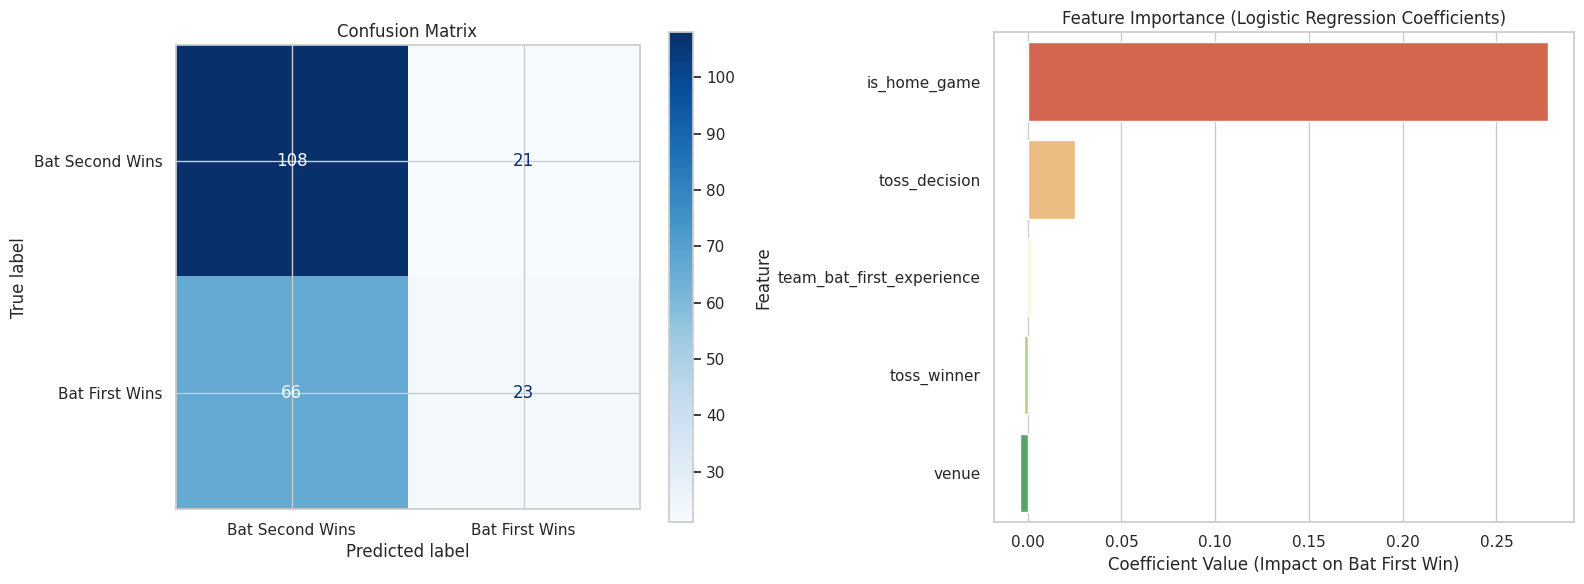

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Calculate and print Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

# 2. Compute and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bat Second Wins', 'Bat First Wins'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

disp.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix')

# 3. Extract and Visualize Feature Importance (Coefficients)
# We use X.columns to match coefficients with their respective features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_reg.coef_[0]
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='RdYlGn', ax=ax2)
ax2.set_title('Feature Importance (Logistic Regression Coefficients)')
ax2.set_xlabel('Coefficient Value (Impact on Bat First Win)')

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code block generated a FutureWarning because `palette` was used without assigning `hue`. I will update the `sns.barplot` call to assign `y` to `hue` and set `legend=False` to comply with the latest Seaborn API and resolve the warning while maintaining the visualization of feature importance.



Model Accuracy: 0.6009


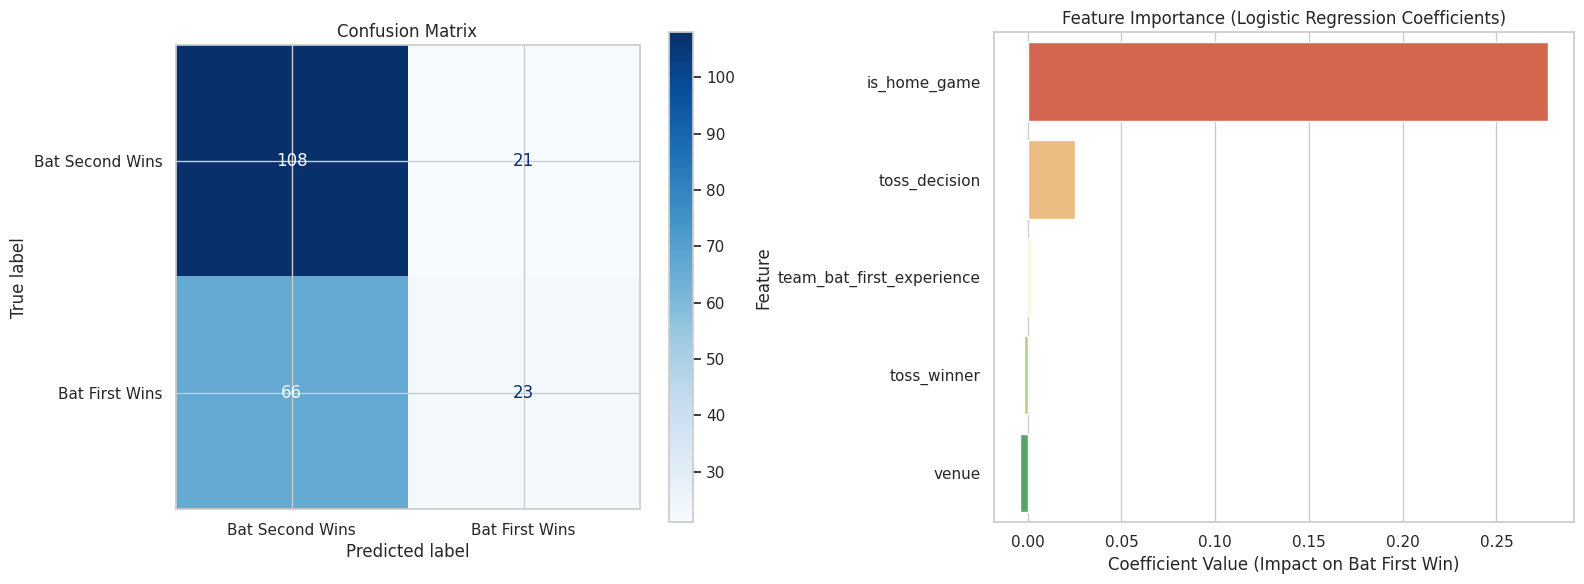

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Calculate and print Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 2. Compute and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bat Second Wins", "Bat First Wins"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

disp.plot(ax=ax1, cmap="Blues")
ax1.set_title("Confusion Matrix")

# 3. Extract and Visualize Feature Importance (Coefficients)
# We use X.columns to match coefficients with their respective features
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": log_reg.coef_[0]
}).sort_values(by="Importance", ascending=False)

# Assign y to hue and set legend=False to fix the palette warning
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="RdYlGn", hue="Feature", legend=False, ax=ax2)
ax2.set_title("Feature Importance (Logistic Regression Coefficients)")
ax2.set_xlabel("Coefficient Value (Impact on Bat First Win)")

plt.tight_layout()
plt.show()

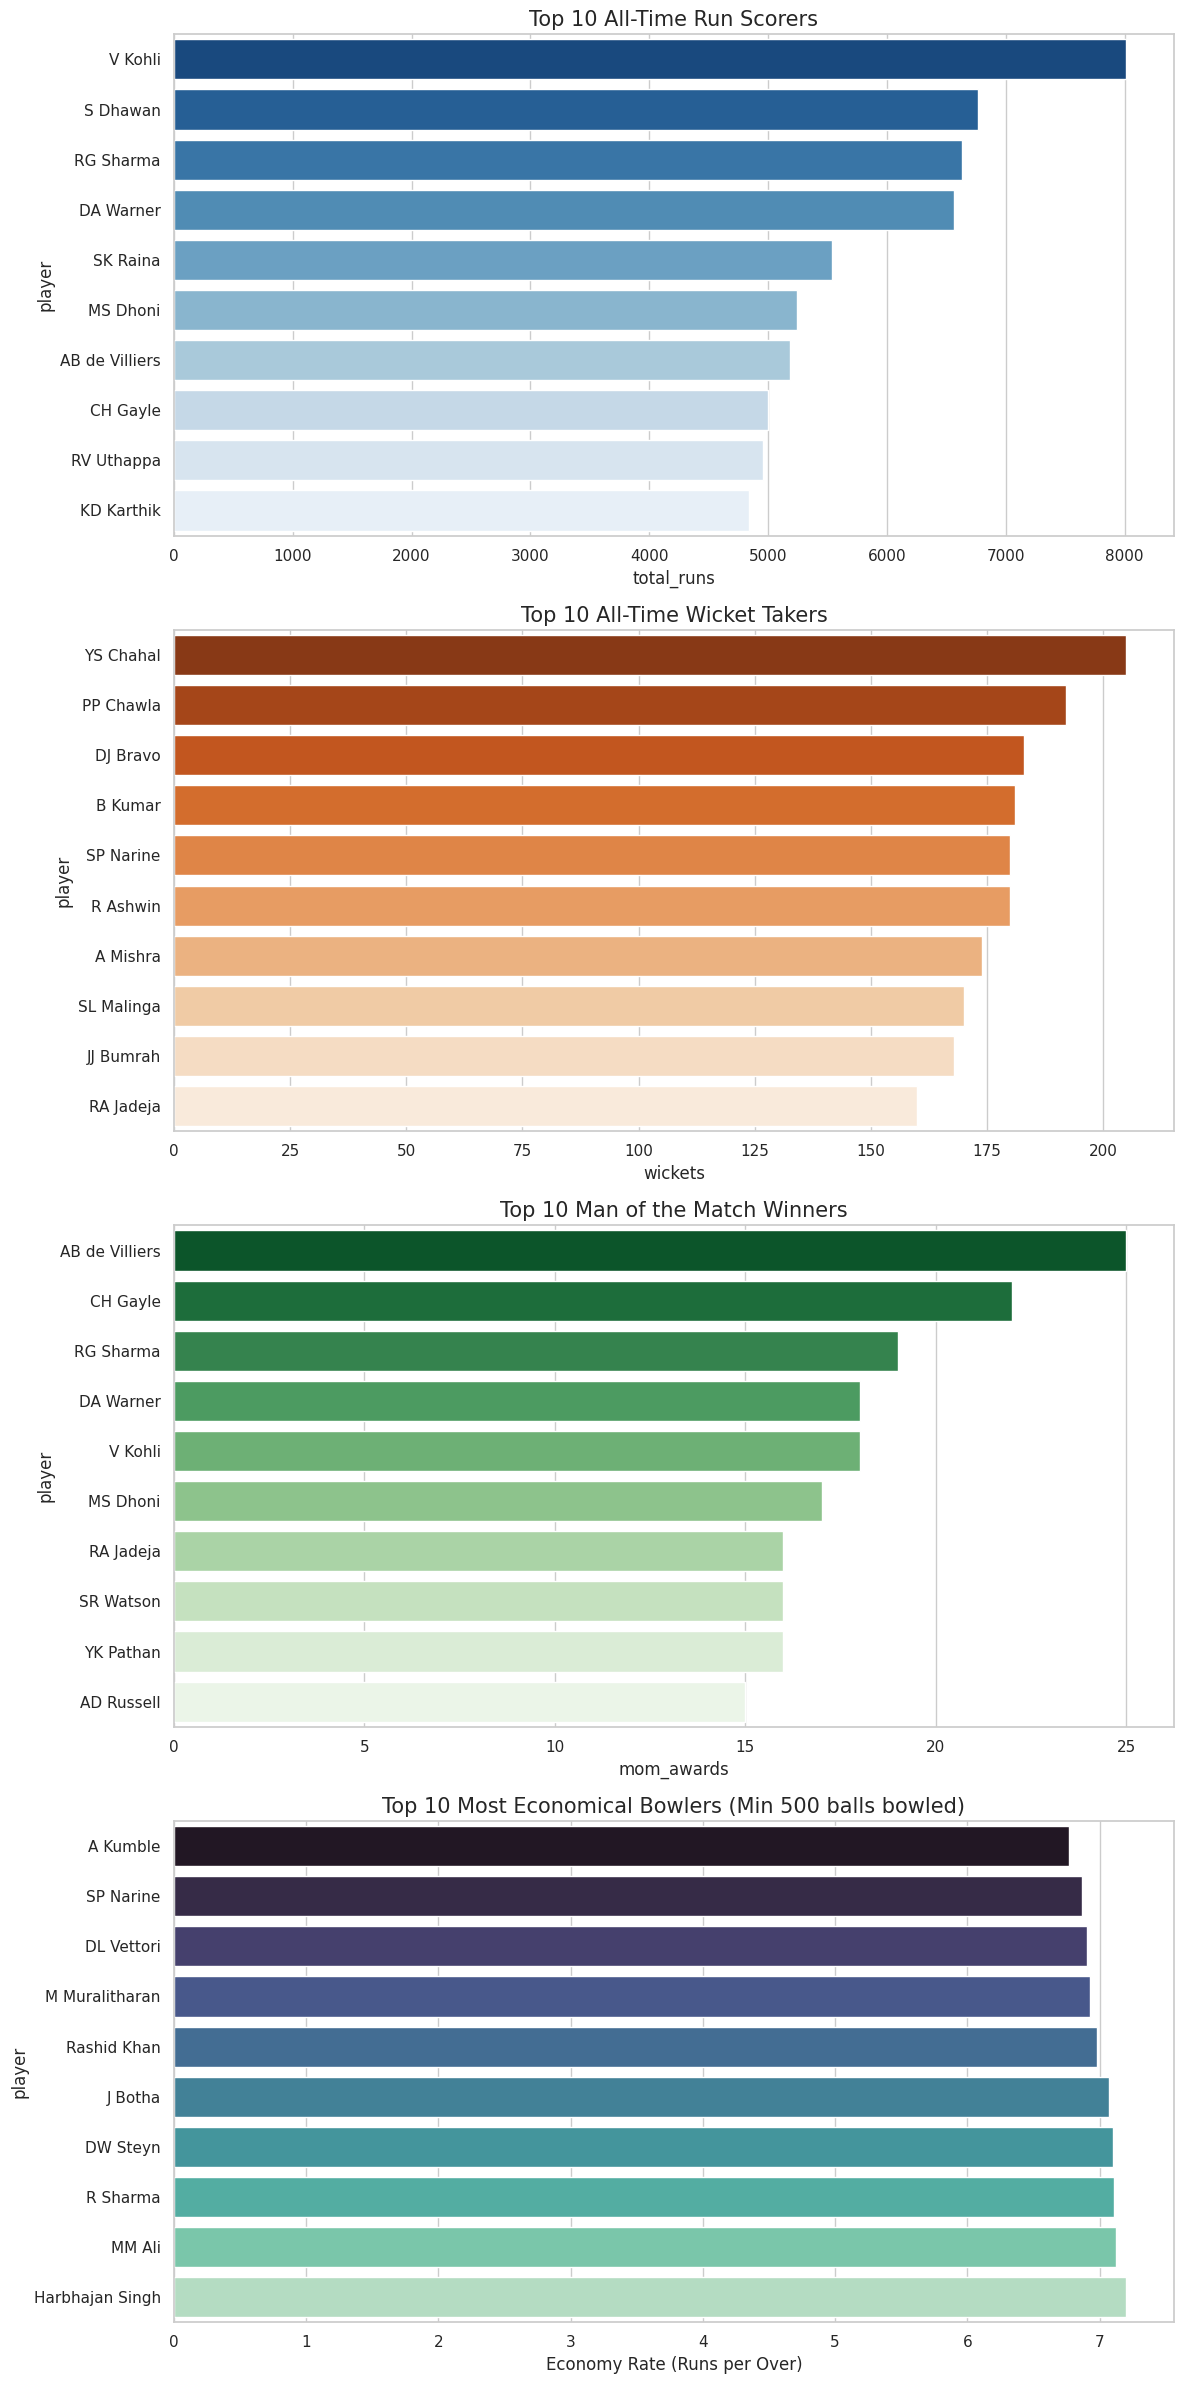

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter bowlers with at least 500 balls bowled for a fair economy comparison
efficient_bowlers = merged_stats[merged_stats['balls_bowled'] >= 500].sort_values(by='economy', ascending=True).head(10)

# Extend the dashboard to 4 plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(12, 24))

# 1. Top 10 Run Scorers
top_runs = merged_stats.sort_values(by='total_runs', ascending=False).head(10)
sns.barplot(ax=axes[0], x='total_runs', y='player', data=top_runs, hue='player', palette='Blues_r', legend=False)
axes[0].set_title('Top 10 All-Time Run Scorers', fontsize=15)

# 2. Top 10 Wicket Takers
top_wickets = merged_stats.sort_values(by='wickets', ascending=False).head(10)
sns.barplot(ax=axes[1], x='wickets', y='player', data=top_wickets, hue='player', palette='Oranges_r', legend=False)
axes[1].set_title('Top 10 All-Time Wicket Takers', fontsize=15)

# 3. Top 10 Man of the Match Winners
top_mom = merged_stats.sort_values(by='mom_awards', ascending=False).head(10)
sns.barplot(ax=axes[2], x='mom_awards', y='player', data=top_mom, hue='player', palette='Greens_r', legend=False)
axes[2].set_title('Top 10 Man of the Match Winners', fontsize=15)

# 4. Top 10 Best Economy Rates (Min 500 balls)
sns.barplot(ax=axes[3], x='economy', y='player', data=efficient_bowlers, hue='player', palette='mako', legend=False)
axes[3].set_title('Top 10 Most Economical Bowlers (Min 500 balls bowled)', fontsize=15)
axes[3].set_xlabel('Economy Rate (Runs per Over)')

plt.tight_layout()
plt.show()